In [1]:
import pandas as pd
from ydata_profiling import ProfileReport
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn
import sklearn.pipeline
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LassoCV
from sklearn.ensemble import RandomForestClassifier
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
import warnings
from sklearn.model_selection import cross_val_score
%matplotlib inline

e:\OneDrive\Documents\coding\MLInternship\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv('E:/Downloads/Mall_Customers.csv')

In [3]:
df['Gender'] = LabelEncoder().fit_transform(df['Gender'])


In [4]:
def remove_outliers_iqr(df, columns):
    Q1 = df[columns].quantile(0.25)
    Q3 = df[columns].quantile(0.75)
    IQR = Q3 - Q1
    mask = ~((df[columns] < (Q1 - 1.5 * IQR)) | (df[columns] > (Q3 + 1.5 * IQR))).any(axis=1)
    return df[mask]
df_no_outliers = remove_outliers_iqr(df, df.select_dtypes(include=[np.number]).columns)
print('Original shape:', df.shape)
print('Shape after outlier removal:', df_no_outliers.shape)
df = df_no_outliers.reset_index(drop=True)

Original shape: (200, 5)
Shape after outlier removal: (198, 5)


In [5]:
ftrs = df[['Gender','Age','Annual Income (k$)','Spending Score (1-100)']]


In [6]:
scalar = StandardScaler()
ftrs_scaled = scalar.fit_transform(ftrs)

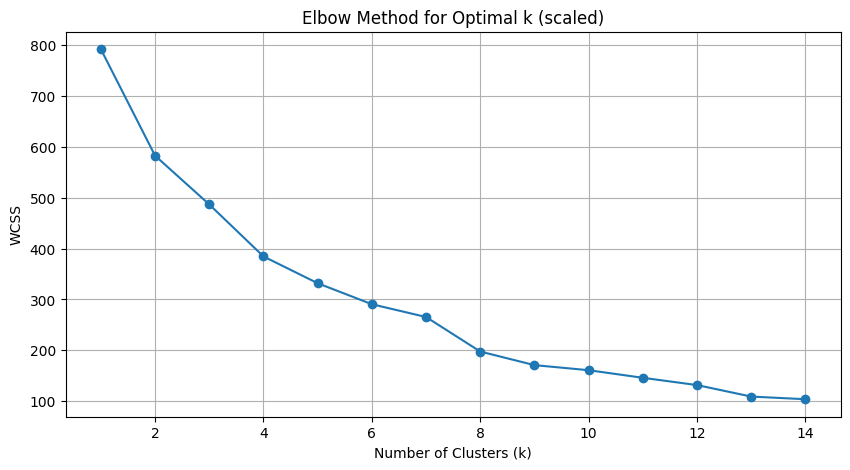

In [7]:
wcss = [] #within cluster sum of squares used evaluate how well the data points are clustered around their respective centroids in K-Means.


for k in range (1,15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_scaled)
    wcss.append(kmeans.inertia_)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 15), wcss, marker='o')
plt.title('Elbow Method for Optimal k (scaled)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.grid(True)
plt.show()

[0.25090045818546425, 0.27177366124271, 0.2989514866332462, 0.30457285645416543, 0.3186844232443084, 0.3123224456356529, 0.3914697863773164, 0.4043582839406131, 0.38177771336302013, 0.399448258693048, 0.41278002020609, 0.4365793724587708, 0.413017299499747]


Text(0.5, 0, 'Number of Clusters (k)')

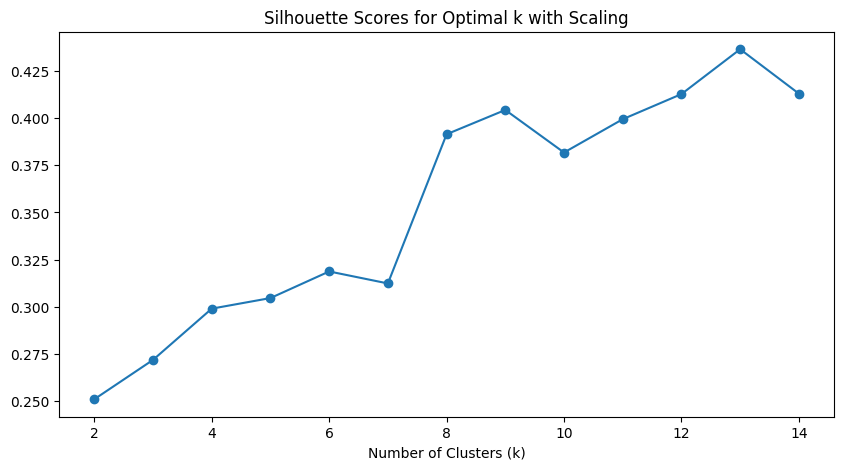

In [8]:
silhouette_scores = []
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(ftrs_scaled)
    score = silhouette_score(ftrs_scaled, kmeans.labels_)
    silhouette_scores.append(score)
print (silhouette_scores)

plt.figure(figsize=(10, 5))
plt.plot(range(2, 15), silhouette_scores, marker='o')
plt.title('Silhouette Scores for Optimal k with Scaling')
plt.xlabel('Number of Clusters (k)')

highest silhoutte score with scaled values(0.436) at k=13 THIS IS WITHOUT SCALING


In [9]:
pca = PCA(n_components=2)
ftrs_pca = pca.fit_transform(ftrs_scaled)

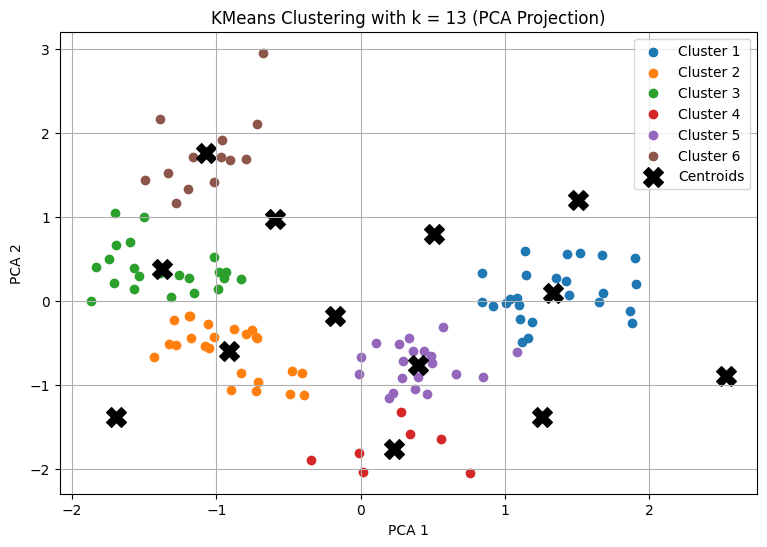

In [10]:
kmeans_final = KMeans(n_clusters=13, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(9,6))
for i in range(6):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 13 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

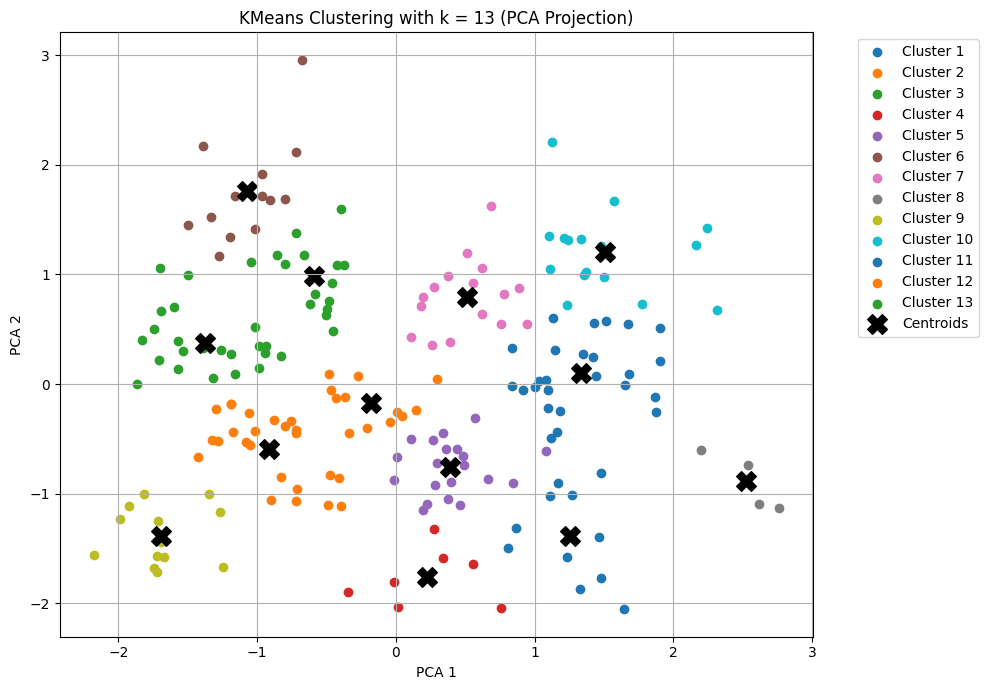

In [11]:
# KMeans clustering with k=13 and PCA projection for visualization
kmeans_final = KMeans(n_clusters=13, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(10,7))
for i in range(13):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 13 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# 1. Fit KMeans with optimal k ( f9rom Silhouette Score)
kmeans = KMeans(n_clusters=13, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(ftrs_scaled)  # ftrs_scaled already defined earlier

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(ftrs_scaled, cluster_labels, test_size=0.2, random_state=42)



# 3. Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 4. Grid Search with CV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# 5. Best model
best_rf = grid_search.best_estimator_
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

# 6. Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# 7. Accuracy Metrics
print("\n=== Model Evaluation ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix (Test Data):\n", confusion_matrix(y_test, y_test_pred))

# 8. Cross-validation
cv_scores = cross_val_score(best_rf, ftrs_scaled, cluster_labels, cv=5)
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", np.mean(cv_scores))
print("Standard Deviation     :", np.std(cv_scores))

# 9. Assign new example to cluster
example = pd.DataFrame([[1, 35, 60, 50]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)  # ensure scalar was already fitted
assigned_cluster = kmeans.predict(example_scaled)
print("\nExample Customer:", example.values[0])
print("Predicted Cluster:", assigned_cluster[0])

Fitting 5 folds for each of 36 candidates, totalling 180 fits


e:\OneDrive\Documents\coding\MLInternship\myenv\Lib\site-packages\sklearn\model_selection\_split.py:811: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Best Parameters from GridSearchCV: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

=== Model Evaluation ===
Train Accuracy: 1.0
Test Accuracy : 1.0

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         4
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         1
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         6
           5       1.00      1.00      1.00         2
           6       1.00      1.00      1.00         2
           7       1.00      1.00      1.00         3
           8       1.00      1.00      1.00         3
           9       1.00      1.00      1.00         2
          10       1.00      1.00      1.00         2
          11       1.00      1.00      1.00         3
          12       1.00      1.00      1.00         4

    accuracy                           

### OVERFITTING MODEL 

CV Accuracy of 0.93



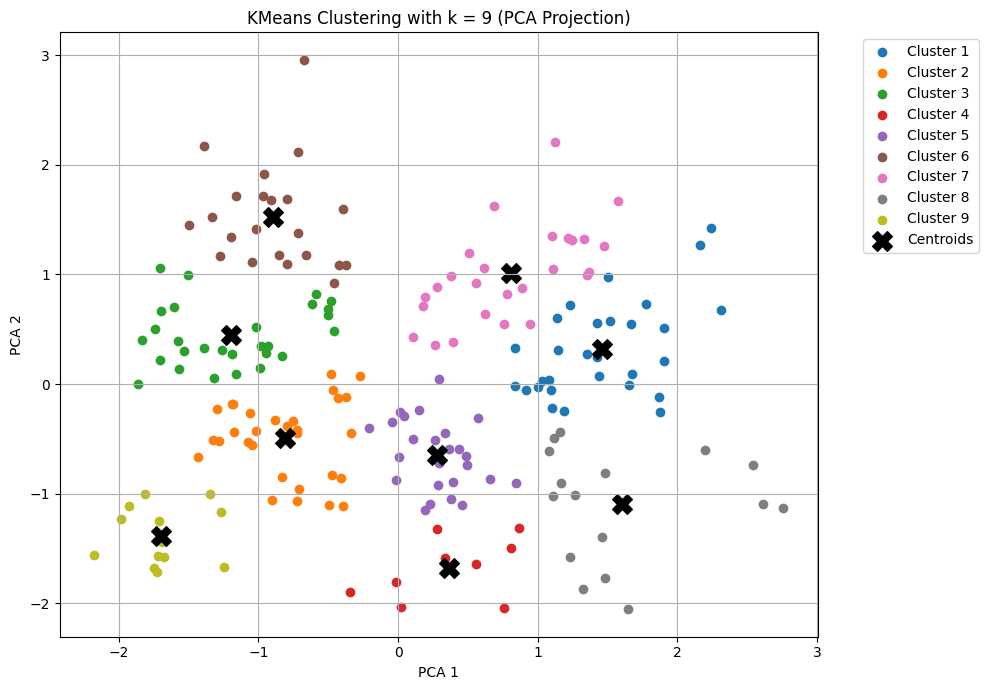

In [52]:
# KMeans clustering with k=13 and PCA projection for visualization
kmeans_final = KMeans(n_clusters=9, init='k-means++', random_state=42)
clusters = kmeans_final.fit_predict(ftrs_pca)
plt.figure(figsize=(10,7))
for i in range(9):
    plt.scatter(ftrs_pca[clusters == i, 0], ftrs_pca[clusters == i, 1], label=f'Cluster {i+1}')
plt.scatter(kmeans_final.cluster_centers_[:, 0], kmeans_final.cluster_centers_[:, 1], c='black', s=200, marker='X', label='Centroids')
plt.title('KMeans Clustering with k = 9 (PCA Projection)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [53]:
# 1. Fit KMeans with optimal k (9 from Silhouette Score)
kmeans = KMeans(n_clusters=9, init='k-means++', random_state=42)
cluster_labels = kmeans.fit_predict(ftrs_scaled)  # ftrs_scaled already defined earlier

# 2. Train-test split
X_train, X_test, y_train, y_test = train_test_split(ftrs_scaled, cluster_labels, test_size=0.2, random_state=42)

# 3. Define parameter grid for Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# 4. Grid Search with CV
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# 5. Best model
best_rf = grid_search.best_estimator_
print("Best Parameters from GridSearchCV:", grid_search.best_params_)

# 6. Predictions
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# 7. Accuracy Metrics
print("\n=== Model Evaluation ===")
print("Train Accuracy:", accuracy_score(y_train, y_train_pred))
print("Test Accuracy :", accuracy_score(y_test, y_test_pred))
print("\nClassification Report (Test Data):\n", classification_report(y_test, y_test_pred))
print("Confusion Matrix (Test Data):\n", confusion_matrix(y_test, y_test_pred))

# 8. Cross-validation
cv_scores = cross_val_score(best_rf, ftrs_scaled, cluster_labels, cv=5)
print("\nCross-Validation Scores:", cv_scores)
print("Mean CV Accuracy       :", np.mean(cv_scores))
print("Standard Deviation     :", np.std(cv_scores))

# 9. Assign new example to cluster
example = pd.DataFrame([[1, 35, 60, 50]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)  # ensure scalar was already fitted
assigned_cluster = kmeans.predict(example_scaled)
print("\nExample Customer:", example.values[0])
print("Predicted Cluster:", assigned_cluster[0])

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters from GridSearchCV: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}

=== Model Evaluation ===
Train Accuracy: 1.0
Test Accuracy : 0.975

Classification Report (Test Data):
               precision    recall  f1-score   support

           0       1.00      1.00      1.00         6
           1       1.00      1.00      1.00         7
           2       1.00      1.00      1.00         4
           3       1.00      1.00      1.00         1
           4       1.00      1.00      1.00         7
           5       1.00      1.00      1.00         4
           6       0.83      1.00      0.91         5
           7       1.00      1.00      1.00         3
           8       1.00      0.67      0.80         3

    accuracy                           0.97        40
   macro avg       0.98      0.96      0.97        40
weighted avg       0.98      0.97      0.97        40

Confusion Matrix (Test Data):

In [54]:
df['Cluster'] = cluster_labels


In [55]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster,Income_per_Age,Spending_to_Income
0,1,1,19,15,39,2,0.789474,2.600000
1,2,1,21,15,81,2,0.714286,5.400000
2,3,0,20,16,6,6,0.800000,0.375000
3,4,0,23,16,77,8,0.695652,4.812500
4,5,0,31,17,40,6,0.548387,2.352941


In [56]:
# Add cluster assignments to both df and ftrs DataFrames
ftrs_scaled_all = scalar.transform(ftrs)
assigned_clusters = kmeans.predict(ftrs_scaled_all)
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = assigned_clusters
ftrs_with_clusters = ftrs.copy()
ftrs_with_clusters['Cluster'] = assigned_clusters
print('df with clusters:')
print(df_with_clusters.head())
print('ftrs with clusters:')
print(ftrs_with_clusters.head())


df with clusters:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1       1   19                  15                      39   
1           2       1   21                  15                      81   
2           3       0   20                  16                       6   
3           4       0   23                  16                      77   
4           5       0   31                  17                      40   

   Cluster  Income_per_Age  Spending_to_Income  
0        2        0.789474            2.600000  
1        2        0.714286            5.400000  
2        6        0.800000            0.375000  
3        8        0.695652            4.812500  
4        6        0.548387            2.352941  
ftrs with clusters:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        2
1       1   21                  15                      81        2
2       0   20     

In [57]:
df['Income_per_Age'] = df['Annual Income (k$)'] / df['Age']

df['Spending_to_Income'] = df['Spending Score (1-100)'] / df['Annual Income (k$)']

In [58]:
cluster_profile = df.groupby('Cluster').agg({
    'Age': ['mean', 'median'],
    'Annual Income (k$)': ['mean', 'median'],
    'Spending Score (1-100)': ['mean', 'median'],
    'Income_per_Age': ['mean', 'median'],
    'Spending_to_Income': ['mean', 'median'],
    'Gender': 'mean'  #encoded as 0/1, mean gives % male/female
}).round(2)

cluster_profile.columns = ['_'.join([str(c) for c in col]).strip() for col in cluster_profile.columns.values]
cluster_profile['Spending_to_Income'] = (
    cluster_profile['Spending Score (1-100)_mean'] / cluster_profile['Annual Income (k$)_mean']
).round(2)

print(cluster_profile)



         Age_mean  Age_median  Annual Income (k$)_mean  \
Cluster                                                  
0           58.04        59.0                    47.63   
1           32.55        32.0                    85.27   
2           25.25        24.0                    41.25   
3           44.60        44.0                    92.33   
4           52.97        50.0                    48.06   
5           38.83        41.0                    83.06   
6           28.53        28.5                    50.10   
7           33.47        32.0                    84.18   
8           25.46        23.0                    25.69   

         Annual Income (k$)_median  Spending Score (1-100)_mean  \
Cluster                                                           
0                             49.0                        38.85   
1                             78.5                        80.59   
2                             44.0                        60.92   
3                         

| Cluster | Avg Age | Income (k\$) | Income/Age | Spending/Income | Gender | 🧠 Segment Insight                                                                                                                                                                                          |
| ------: | ------- | ------------ | ---------- | --------------- | ------ | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
|   **0** | 58.0    | 47.6         | 0.83       | 0.82            | Male   | Older predominantly **male** customers with moderate income and controlled spending. Likely **cautious, loyal, financially conservative**, and not impulsive. Respond better to long-term trust-building and reliability. |
|   **1** | 32.6    | 85.3         | **2.64**   | 0.96            | Female | Young predominantly **female** cluster with **very high income** and moderate-to-high spending. Great candidates for **premium services, exclusive offers**, and lifestyle branding.                                 |
|   **2** | 25.3    | 41.2         | 1.75       | **1.48**        | Female | Mostly Very **young female** segment with modest income but **high spending-to-income ratio**. Likely **impulsive, trend-sensitive**, and easily influenced by social media or aspirational marketing.             |
|   **3** | 44.6    | 92.3         | **2.13**   | 0.23            | Male   | usually High-income **middle-aged males** with very low spending. Likely **value-seekers or savers**. Target with **high-quality guarantees, insurance products**, or **investment-aligned messaging**.             |
|   **4** | 53.0    | 48.1         | 0.92       | 0.89            | Male   | Older **males (mostly)** with low-to-mid income but fair spending. Possibly **habitual buyers** or price-sensitive loyalists. Position **consistent-value products** with **trustworthy brand image**.               |
|   **5** | 38.8    | 83.1         | **2.38**   | 0.17            | Female | predominantly Wealthy **female** customers who barely spend. Likely **investment-oriented, risk-averse**, or highly selective. Reach via **elite services, investments, or personalized one-to-one offerings**.           |
|   **6** | 28.5    | 50.1         | 1.90       | 0.84            | Male   | often **Younger men** with average income and moderate spending. Good fit for **tech, subscriptions**, or **up-sell campaigns**. Not premium, but brand-engageable.                                               |
|   **7** | 33.5    | 84.2         | **2.58**   | 0.98            | Female | Usually **Young high-income females** who spend actively. One of the **most profitable segments**. Highly responsive to **premium goods, fashion, tech**, and exclusive community access.                           |
|   **8** | 25.5    | 25.7         | 1.06       | **3.14**        | Male   | mostly Very **young males** with **very low income** but **extremely high spending**. Likely **aspirational or impulsive buyers**, potentially credit-reliant. Use **flash sales, discounts, urgency tactics**.    |


| Cluster | Targeting Strategy                                                                        |
| ------: | ----------------------------------------------------------------------------------------- |
|   **0** | Emphasize **trust, quality**, and reliability. Avoid trends; offer long-term value.       |
|   **1** | Target with **premium, curated offers**. Use aesthetic, lifestyle-focused campaigns.      |
|   **2** | Use **trendy, influencer-led** marketing. Promote urgency: flash sales, limited drops.    |
|   **3** | Highlight **value, logic, and ROI**. Rational messaging and quality assurance work best.  |
|   **4** | Simple, **no-nonsense communication**. Push durability, smart buying, and efficiency.     |
|   **5** | Appeal via **exclusive, private offers**. Use premium yet subtle marketing.               |
|   **6** | Offer **tech-driven rewards**, subscriptions, or performance-focused deals.               |
|   **7** | Push **flagship launches, VIP access**, and bold brand presence. Highly profitable group. |
|   **8** | Drive with **emotional and urgency-based campaigns**. Mobile-first, hype-driven content.  |


In [59]:
example = pd.DataFrame([[1, 22, 100, 87]], columns=['Gender','Age','Annual Income (k$)','Spending Score (1-100)'])
example_scaled = scalar.transform(example)
assigned_cluster = kmeans.predict(example_scaled)
print('Example data:', example.values[0])
print('Assigned to cluster:', assigned_cluster[0])

Example data: [  1  22 100  87]
Assigned to cluster: 7


In [60]:
import joblib


joblib.dump(kmeans, "kmeans_model.pkl")
joblib.dump(scalar, "scaler.pkl")
joblib.dump(best_rf, "random_forest_model.pkl")


['random_forest_model.pkl']

In [61]:
joblib.dump(kmeans, "kmeans_model.pkl")



['kmeans_model.pkl']

In [62]:

joblib.dump(scalar, "scaler.pkl")


['scaler.pkl']